In [1]:
# Capestone Project: Belgium

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings("ignore")

In [3]:
belgium_df = pd.read_csv("Belgium.csv")
belgium_df.head()

,ID,Host ID,Host Name,Host Since,Host Response Rate,Host Listings Count,Host Total Listings Count,City,State,Zipcode,Country,Property Type,Room Type,Accommodates,Bathrooms,Bedrooms,Beds,Bed Type,Amenities,Price,Weekly Price,Monthly Price,Security Deposit,Cleaning Fee,Guests Included,Extra People,Minimum Nights,Maximum Nights,Number of Reviews,Review Scores Rating,Cancellation Policy,Reviews per Month
0,18352107,12582463,Veronique,25-02-2014,97.0,4.0,4.0,Woluwe-Saint-Lambert,Bruxelles,1200,Belgium,Guesthouse,Private room,2,1.0,1.0,1.0,Real Bed,"Wireless Internet,Kitchen,Essentials,Lock on b...",26.0,NaN,NaN,300.0,NaN,1,15,3,1125,1,100.0,flexible,1.00
1,15881481,50702141,Mathias,07-12-2015,100.0,1.0,1.0,Woluwe-Saint-Pierre,Bruxelles,1150,Belgium,Apartment,Entire home/apt,2,1.0,1.0,1.0,Real Bed,"Internet,Wireless Internet,Kitchen,Heating,Was...",75.0,NaN,NaN,NaN,NaN,1,0,2,1125,7,91.0,strict,1.18
2,469616,2330339,Carine,09-05-2012,100.0,1.0,1.0,bruxelles,woluwe saint pierre,1150,Belgium,House,Entire home/apt,4,1.0,2.0,2.0,Real Bed,"TV,Internet,Wireless Internet,Kitchen,Free par...",110.0,600.0,2100.0,NaN,NaN,1,0,2,1125,0,NaN,flexible,NaN
3,8594409,44455307,Nathalie,17-09-2015,NaN,1.0,1.0,Woluwe-Saint-Pierre,Bruxelles,1150,Belgium,Apartment,Entire home/apt,2,1.5,1.0,1.0,Real Bed,"TV,Internet,Kitchen,Buzzer/wireless intercom,H...",60.0,NaN,NaN,NaN,NaN,1,0,2,1125,4,100.0,flexible,0.38
4,17149960,6592332,Isabelle,27-05-2013,100.0,2.0,2.0,Woluwe-Saint-Pierre,Bruxelles,1150,Belgium,Apartment,Private room,2,1.0,1.0,1.0,Real Bed,"TV,Cable TV,Wireless Internet,Kitchen,Free par...",55.0,NaN,NaN,NaN,20.0,1,10,5,9,0,NaN,flexible,NaN


In [4]:
belgium_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7419 entries, 0 to 7418
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         7419 non-null   int64  
 1   Host ID                    7419 non-null   int64  
 2   Host Name                  7418 non-null   object 
 3   Host Since                 7418 non-null   object 
 4   Host Response Rate         5762 non-null   float64
 5   Host Listings Count        7418 non-null   float64
 6   Host Total Listings Count  7418 non-null   float64
 7   City                       7388 non-null   object 
 8   State                      7360 non-null   object 
 9   Zipcode                    7272 non-null   object 
 10  Country                    7419 non-null   object 
 11  Property Type              7419 non-null   object 
 12  Room Type                  7419 non-null   object 
 13  Accommodates               7419 non-null   int64

### DATA PREPROCESSING PROCESS

In [5]:
belgium_df.columns = belgium_df.columns.str.lower().str.replace(" ", "_")


numeric_cols_belgium = [
    "host_response_rate", "host_listings_count", "host_total_listings_count",
    "accommodates", "bathrooms", "bedrooms", "beds", "price",
    "weekly_price", "monthly_price", "security_deposit",
    "cleaning_fee", "guests_included", "extra_people",
    "minimum_nights", "maximum_nights", "number_of_reviews",
    "review_scores_rating", "reviews_per_month"
]

for col in numeric_cols_belgium:
    belgium_df[col] = pd.to_numeric(belgium_df[col], errors="coerce")

# Changing Date Format

belgium_df["host_since"] = pd.to_datetime(belgium_df["host_since"],format="%d-%m-%Y",errors="coerce")
belgium_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7419 entries, 0 to 7418
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id                         7419 non-null   int64         
 1   host_id                    7419 non-null   int64         
 2   host_name                  7418 non-null   object        
 3   host_since                 7418 non-null   datetime64[ns]
 4   host_response_rate         5762 non-null   float64       
 5   host_listings_count        7418 non-null   float64       
 6   host_total_listings_count  7418 non-null   float64       
 7   city                       7388 non-null   object        
 8   state                      7360 non-null   object        
 9   zipcode                    7272 non-null   object        
 10  country                    7419 non-null   object        
 11  property_type              7419 non-null   object        
 12  room_t

### MISSING VALUE ANALYSIS

In [6]:
print("Before Missing Value Treatment")
belgium_df.isnull().sum()

Before Missing Value Treatment


id                              0
host_id                         0
host_name                       1
host_since                      1
host_response_rate           1657
host_listings_count             1
host_total_listings_count       1
city                           31
state                          59
zipcode                       147
country                         0
property_type                   0
room_type                       0
accommodates                    0
bathrooms                      13
bedrooms                        9
beds                           14
bed_type                        0
amenities                      61
price                           4
weekly_price                 5201
monthly_price                5545
security_deposit             4809
cleaning_fee                 3361
guests_included                 0
extra_people                    0
minimum_nights                  0
maximum_nights                  0
number_of_reviews               0
review_scores_

In [7]:
# Drop Highly Missing Columns
# As there is more than 70% of data is missing in this columns & Fill NaNs with Zero

belgium_df = belgium_df.drop(columns=['monthly_price', 'weekly_price'])

cols_to_fill_zero = [
    'host_listings_count', 'host_total_listings_count',
    'security_deposit', 'cleaning_fee',
    'reviews_per_month', 'review_scores_rating'
]

belgium_df[cols_to_fill_zero] = belgium_df[cols_to_fill_zero].fillna(0)

# We use Median to handle outliers as more no.of data is missing

belgium_df['host_response_rate'] = belgium_df['host_response_rate'].fillna(belgium_df['host_response_rate'].median())

belgium_df['price'] = belgium_df['price'].fillna(belgium_df['price'].median())


mode_cols = ['amenities', 'beds', 'bedrooms','bathrooms', 'host_name','host_since', 'zipcode']

for col in mode_cols:
    belgium_df[col] = belgium_df[col].fillna(belgium_df[col].mode()[0])

### Zipcode, City and State Cleaning

In [8]:
belgium_df['zipcode'].unique()

array(['1200', '1150', '1060', '1040', '1140', '1190', '1083', '1050',
       '1000', '1090', '1081', '1080', '1020', '1070', '1160', '1082',
       '1030', '1180', '1210', '2000', '2140', '2060', '2018', '2600',
       '2100', '2050', '2180', '2020', '2610', '11 20', '1120', 'Xxx',
       '2660', '2170', '2040', '1050\n1050', '1170', '1630', '2950',
       '1212', 'Brussels', '1130', '2008', '1700', 'B-1000', '1800',
       '1620'], dtype=object)

In [9]:
belgium_df['zipcode'].nunique()

47

In [10]:
belgium_df['city'].nunique()

76

In [11]:
belgium_df['city'].unique()

array(['Woluwe-Saint-Lambert', 'Woluwe-Saint-Pierre', 'bruxelles',
       'Saint-Gilles', 'Sint-Gillis', 'Etterbeek', 'Evere', 'Forest',
       'Ganshoren', 'Ixelles', 'Jette', 'Koekelberg',
       'Molenbeek-Saint-Jean', 'Bruxelles', 'Brussels',
       'Sint-Jans-Molenbeek', 'Ville de Bruxelles', 'City of Brussels',
       'Brussel', 'Anderlecht', 'Auderghem', 'Berchem-Sainte-Agathe',
       'Schaerbeek', 'Schaarbeek', 'Uccle', 'Woluwé-Saint-Lambert',
       'Saint-Josse-ten-Noode', 'Elsene', nan, 'Sint Jans Molenbeek',
       'Antwerpen', 'Antwerp', 'Vorst', 'Louise', 'Watermael-Boitsfort',
       'Sint-Lambrechts-Woluwe', 'Ukkel', 'UCCLE', 'Laken', 'Linkebeek',
       'Sint-Joost-ten-Node', 'Sint Jans', 'Laeken',
       'Woluwe Saint Pierre', '1081', 'WATERMAEL BOITSFORT', 'Brüssel',
       'Brussels - Anderlecht', 'Bruxelles centre ville', 'tours et taxi',
       'BORGERHOUT (ANTWERPEN)', 'Bruksela', 'ixelles', 'Wilrijk',
       'Ixelles/Elsene', 'Sint-Pieters-Woluwe', 'anderlecht'

In [12]:
belgium_df['state'].nunique()

48

In [13]:
belgium_df['state'].unique()

array(['Bruxelles', 'woluwe saint pierre', 'Brussels',
       'Brussels Hoofdstedelijk Gewest', 'Brussel', nan,
       'Region Brüssel-Hauptstadt', 'Vlaanderen', 'Flanders',
       'Flemish Region', 'Vlaams Gewest', 'Antwerpen', 'Belgique',
       'Deurne', 'BRUXELLES', '1000', 'Berchem', 'Région Flamande',
       'Neuve', 'laeken', 'Jette', 'Woluwe Saint Lambert',
       'Région de Bruxelles-Capitale', 'Koekelberg', 'Propre', 'Laeken',
       'Belgium', 'Brussel Hoofdstedelijk Gewest', 'Sint-joost-ten-node',
       '布鲁塞尔首都区', 'Antwerp', '1060', 'Ixelles',
       'Regione di Bruxelles-Capitale', 'Region Stołeczny Brukseli',
       'Brussels Capital', 'Bruselas', 'region de Bruxelles Capitale',
       'BELGIQUE', 'bruxelles', 'Quartier Européen', 'Chatelain',
       'België', 'Jan vanhoenackerstraat 60', 'Neuf',
       'Brussels hoofdstedelijk gewest', 'Etterbeek', 'Anderlecht',
       'Bruxelles-Capitale'], dtype=object)

In [14]:
# Dictionary to fix known Belgian zipcode issues
zip_fix_dict = {
    'Xxx': np.nan,            
    'Brussels': np.nan,       
    '11 20': np.nan,          
    '1050\n1050': '1050',     
    'B-1000': '1000',       
    '2610': np.nan          
}

belgium_df["zipcode"] = (belgium_df["zipcode"].astype(str).str.strip().replace(zip_fix_dict))

valid_zip_mask = belgium_df["zipcode"].str.fullmatch(r"\d{4}", na=False)
belgium_df.loc[~valid_zip_mask, "zipcode"] = np.nan

# 3. Fill remaining NaNs with the most common zipcode
belgium_df["zipcode"] = belgium_df["zipcode"].fillna(belgium_df["zipcode"].mode()[0])

# 4. Final check
print(belgium_df["zipcode"].unique())


['1200' '1150' '1060' '1040' '1140' '1190' '1083' '1050' '1000' '1090'
 '1081' '1080' '1020' '1070' '1160' '1082' '1030' '1180' '1210' '2000'
 '2140' '2060' '2018' '2600' '2100' '2050' '2180' '2020' '1120' '2660'
 '2170' '2040' '1170' '1630' '2950' '1212' '1130' '2008' '1700' '1800'
 '1620']


In [15]:
belgium_df = belgium_df.dropna(subset=['city', 'state'])

In [16]:
# Cleaning and Standardizing City Names
# This function removes noise, multilingual values,
# arrondissement details, and standardizes city names

# CHANGING CITY COLUMN (BELGIUM)

city_mapping = {
    # --- Brussels-Capital Region ---
    '1000': 'Brussels',
    '1020': 'Laeken',
    '1030': 'Schaerbeek',
    '1040': 'Etterbeek',
    '1050': 'Ixelles',
    '1060': 'Saint-Gilles',
    '1070': 'Anderlecht',
    '1080': 'Molenbeek-Saint-Jean',
    '1081': 'Koekelberg',
    '1082': 'Berchem-Sainte-Agathe',
    '1083': 'Ganshoren',
    '1090': 'Jette',
    '1120': 'Neder-Over-Heembeek',
    '1130': 'Haren',
    '1140': 'Evere',
    '1150': 'Woluwe-Saint-Pierre',
    '1160': 'Auderghem',
    '1170': 'Watermael-Boitsfort',
    '1180': 'Uccle',
    '1190': 'Forest',
    '1200': 'Woluwe-Saint-Lambert',
    '1210': 'Saint-Josse-ten-Noode',
    '1212': 'Brussels (EU Quarter)',

    # --- Antwerp (city & districts) ---
    '2000': 'Antwerp',
    '2008': 'Antwerp',
    '2018': 'Antwerp',
    '2020': 'Antwerp',
    '2040': 'Antwerp',
    '2050': 'Antwerp',
    '2060': 'Antwerp',
    '2100': 'Deurne',
    '2140': 'Borgerhout',
    '2170': 'Merksem',
    '2180': 'Ekeren',
    '2600': 'Berchem',
    '2660': 'Hoboken',

    # --- Flemish Brabant / Antwerp Province ---
    '1620': 'Drogenbos',
    '1630': 'Linkebeek',
    '1700': 'Dilbeek',
    '1800': 'Vilvoorde',
    '2950': 'Kapellen'
}


belgium_df['city'] = belgium_df['zipcode'].map(city_mapping)

print(belgium_df['city'].unique())

['Woluwe-Saint-Lambert' 'Woluwe-Saint-Pierre' 'Saint-Gilles' 'Etterbeek'
 'Evere' 'Forest' 'Ganshoren' 'Ixelles' 'Brussels' 'Jette' 'Koekelberg'
 'Molenbeek-Saint-Jean' 'Laeken' 'Anderlecht' 'Auderghem'
 'Berchem-Sainte-Agathe' 'Schaerbeek' 'Uccle' 'Saint-Josse-ten-Noode'
 'Antwerp' 'Borgerhout' 'Berchem' 'Deurne' 'Ekeren' 'Neder-Over-Heembeek'
 'Hoboken' 'Merksem' 'Watermael-Boitsfort' 'Kapellen'
 'Brussels (EU Quarter)' 'Haren' 'Dilbeek' 'Vilvoorde' 'Drogenbos']


In [17]:
# Fill Missing State Using City Mapping (Belgium)
# Maps cleaned city names to Belgian regions

# Map CITY Names to STATE / REGION (Belgium)
# This dictionary maps cleaned city names
# to their corresponding Belgian regions

city_to_state = {
    # --- Brussels-Capital Region ---
    'Brussels': 'Brussels-Capital Region',
    'Brussels (EU Quarter)': 'Brussels-Capital Region',
    'Anderlecht': 'Brussels-Capital Region',
    'Auderghem': 'Brussels-Capital Region',
    'Berchem-Sainte-Agathe': 'Brussels-Capital Region',
    'Etterbeek': 'Brussels-Capital Region',
    'Evere': 'Brussels-Capital Region',
    'Forest': 'Brussels-Capital Region',
    'Ganshoren': 'Brussels-Capital Region',
    'Ixelles': 'Brussels-Capital Region',
    'Jette': 'Brussels-Capital Region',
    'Koekelberg': 'Brussels-Capital Region',
    'Laeken': 'Brussels-Capital Region',
    'Molenbeek-Saint-Jean': 'Brussels-Capital Region',
    'Saint-Gilles': 'Brussels-Capital Region',
    'Saint-Josse-ten-Noode': 'Brussels-Capital Region',
    'Schaerbeek': 'Brussels-Capital Region',
    'Uccle': 'Brussels-Capital Region',
    'Watermael-Boitsfort': 'Brussels-Capital Region',
    'Woluwe-Saint-Lambert': 'Brussels-Capital Region',
    'Woluwe-Saint-Pierre': 'Brussels-Capital Region',
    'Haren': 'Brussels-Capital Region',
    'Neder-Over-Heembeek': 'Brussels-Capital Region',

    # --- Flemish Region ---
    'Antwerp': 'Flemish Region',
    'Berchem': 'Flemish Region',
    'Borgerhout': 'Flemish Region',
    'Deurne': 'Flemish Region',
    'Ekeren': 'Flemish Region',
    'Hoboken': 'Flemish Region',
    'Merksem': 'Flemish Region',
    'Kapellen': 'Flemish Region',
    'Dilbeek': 'Flemish Region',
    'Vilvoorde': 'Flemish Region',

    # --- Walloon Region ---
    'Drogenbos': 'Walloon Region'
}

# Apply CITY → STATE Mapping
# Only fills missing state values
belgium_df['state'] = belgium_df['city'].map(city_to_state)



print(belgium_df['state'].unique())

['Brussels-Capital Region' 'Flemish Region' 'Walloon Region']


In [18]:
print("After Missing Value Treatment")
belgium_df.isnull().sum()

After Missing Value Treatment


id                           0
host_id                      0
host_name                    0
host_since                   0
host_response_rate           0
host_listings_count          0
host_total_listings_count    0
city                         0
state                        0
zipcode                      0
country                      0
property_type                0
room_type                    0
accommodates                 0
bathrooms                    0
bedrooms                     0
beds                         0
bed_type                     0
amenities                    0
price                        0
security_deposit             0
cleaning_fee                 0
guests_included              0
extra_people                 0
minimum_nights               0
maximum_nights               0
number_of_reviews            0
review_scores_rating         0
cancellation_policy          0
reviews_per_month            0
dtype: int64

### OUTLIERS ANALYSIS

In [19]:
num_cols = belgium_df.select_dtypes(include=['int64', 'float64']).columns

outlier_summary_before = {}

for col in num_cols:
    Q1 = belgium_df[col].quantile(0.25)
    Q3 = belgium_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = belgium_df[
        (belgium_df[col] < lower_limit) | (belgium_df[col] > upper_limit)
    ].shape[0]

    outlier_summary_before[col] = outliers

outlier_summary_before

{'id': 0,
 'host_id': 442,
 'host_response_rate': 1731,
 'host_listings_count': 1297,
 'host_total_listings_count': 1297,
 'accommodates': 168,
 'bathrooms': 1319,
 'bedrooms': 2301,
 'beds': 574,
 'price': 385,
 'security_deposit': 419,
 'cleaning_fee': 194,
 'guests_included': 390,
 'extra_people': 184,
 'minimum_nights': 537,
 'maximum_nights': 40,
 'number_of_reviews': 832,
 'review_scores_rating': 1593,
 'reviews_per_month': 592}

In [20]:
exclude_cols = [
    'host_id', 'guests_included', 'host_listings_count',
    'host_response_rate', 'bathrooms',
    'bedrooms', 'beds', 'price'
]

num_cols = belgium_df.select_dtypes(include=['int64', 'float64']).columns
num_cols = [col for col in num_cols if col not in exclude_cols]

for col in num_cols:
    Q1 = belgium_df[col].quantile(0.25)
    Q3 = belgium_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    belgium_df[col] = belgium_df[col].mask(belgium_df[col] < lower_limit, lower_limit)
    belgium_df[col] = belgium_df[col].mask(belgium_df[col] > upper_limit, upper_limit)

In [21]:
num_cols = belgium_df.select_dtypes(include=['int64', 'float64']).columns
num_cols = [col for col in num_cols if col not in exclude_cols]

outlier_summary_after = {}

for col in num_cols:
    Q1 = belgium_df[col].quantile(0.25)
    Q3 = belgium_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = belgium_df[(belgium_df[col] < lower_limit) | (belgium_df[col] > upper_limit)].shape[0]
    outlier_summary_after[col] = outliers

outlier_summary_after

{'id': 0,
 'host_total_listings_count': 0,
 'accommodates': 0,
 'security_deposit': 0,
 'cleaning_fee': 0,
 'extra_people': 0,
 'minimum_nights': 0,
 'maximum_nights': 0,
 'number_of_reviews': 0,
 'review_scores_rating': 0,
 'reviews_per_month': 0}

In [22]:
count_columns = ["accommodates", "number_of_reviews", "guests_included"]

for column in count_columns:
    belgium_df[column] = (pd.to_numeric(belgium_df[column], errors="coerce").round().astype("Int64"))

In [23]:
# Featuring Date and Amenities Columns

In [24]:
# Date Columns
# Extract year,month number, month name, week number

belgium_df["host_year"] = belgium_df["host_since"].dt.year
belgium_df["host_month"] = belgium_df["host_since"].dt.month
belgium_df["host_month_name"] = belgium_df["host_since"].dt.month_name()
belgium_df["host_week"] = belgium_df["host_since"].dt.isocalendar().week

In [25]:
belgium_df["amenities"] = belgium_df["amenities"].fillna("")

amenities_clean_list = []
amenity_count_list = []

for value in belgium_df["amenities"]:
    
    value = str(value)
    
    split_items = value.split(",")
    
    clean_items = []
    
    for item in split_items:
        item = item.strip()
        
        if item == "" or item.lower() == "nan":
            continue
        
        if item.startswith("translation"):
            continue
        
        clean_items.append(item)
    
    amenity_count_list.append(len(clean_items))
    
    if len(clean_items) == 0:
        amenities_clean_list.append("No Amenities Listed")
    else:
        amenities_clean_list.append(", ".join(clean_items))

belgium_df["amenities_clean"] = amenities_clean_list
belgium_df["amenity_count"] = amenity_count_list

In [26]:
belgium_df.head()

,id,host_id,host_name,host_since,host_response_rate,host_listings_count,host_total_listings_count,city,state,zipcode,country,property_type,room_type,accommodates,bathrooms,bedrooms,beds,bed_type,amenities,price,security_deposit,cleaning_fee,guests_included,extra_people,minimum_nights,maximum_nights,number_of_reviews,review_scores_rating,cancellation_policy,reviews_per_month,host_year,host_month,host_month_name,host_week,amenities_clean,amenity_count
0,18352107,12582463,Veronique,2014-02-25,97.0,4.0,3.5,Woluwe-Saint-Lambert,Brussels-Capital Region,1200,Belgium,Guesthouse,Private room,2,1.0,1.0,1.0,Real Bed,"Wireless Internet,Kitchen,Essentials,Lock on b...",26.0,300.0,0.0,1,15,3,1125.0,1,100.0,flexible,1.00,2014,2,February,9,"Wireless Internet, Kitchen, Essentials, Lock o...",7
1,15881481,50702141,Mathias,2015-12-07,100.0,1.0,1.0,Woluwe-Saint-Pierre,Brussels-Capital Region,1150,Belgium,Apartment,Entire home/apt,2,1.0,1.0,1.0,Real Bed,"Internet,Wireless Internet,Kitchen,Heating,Was...",75.0,0.0,0.0,1,0,2,1125.0,7,91.0,strict,1.18,2015,12,December,50,"Internet, Wireless Internet, Kitchen, Heating,...",14
2,469616,2330339,Carine,2012-05-09,100.0,1.0,1.0,Woluwe-Saint-Pierre,Brussels-Capital Region,1150,Belgium,House,Entire home/apt,4,1.0,2.0,2.0,Real Bed,"TV,Internet,Wireless Internet,Kitchen,Free par...",110.0,0.0,0.0,1,0,2,1125.0,0,47.0,flexible,0.00,2012,5,May,19,"TV, Internet, Wireless Internet, Kitchen, Free...",15
3,8594409,44455307,Nathalie,2015-09-17,100.0,1.0,1.0,Woluwe-Saint-Pierre,Brussels-Capital Region,1150,Belgium,Apartment,Entire home/apt,2,1.5,1.0,1.0,Real Bed,"TV,Internet,Kitchen,Buzzer/wireless intercom,H...",60.0,0.0,0.0,1,0,2,1125.0,4,100.0,flexible,0.38,2015,9,September,38,"TV, Internet, Kitchen, Buzzer/wireless interco...",9
4,17149960,6592332,Isabelle,2013-05-27,100.0,2.0,2.0,Woluwe-Saint-Pierre,Brussels-Capital Region,1150,Belgium,Apartment,Private room,2,1.0,1.0,1.0,Real Bed,"TV,Cable TV,Wireless Internet,Kitchen,Free par...",55.0,0.0,20.0,1,10,5,9.0,0,47.0,flexible,0.00,2013,5,May,22,"TV, Cable TV, Wireless Internet, Kitchen, Free...",13


In [27]:
belgium_df.to_csv("Belgium_Cleaned.csv", index=False)
print("Cleaned file saved as belgium_Cleaned.csv")

Cleaned file saved as belgium_Cleaned.csv


# AirBnb Belgium Analysis

In [28]:
belgium_df = pd.read_csv("Belgium_Cleaned.csv")
belgium_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7332 entries, 0 to 7331
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         7332 non-null   int64  
 1   host_id                    7332 non-null   int64  
 2   host_name                  7332 non-null   object 
 3   host_since                 7332 non-null   object 
 4   host_response_rate         7332 non-null   float64
 5   host_listings_count        7332 non-null   float64
 6   host_total_listings_count  7332 non-null   float64
 7   city                       7332 non-null   object 
 8   state                      7332 non-null   object 
 9   zipcode                    7332 non-null   int64  
 10  country                    7332 non-null   object 
 11  property_type              7332 non-null   object 
 12  room_type                  7332 non-null   object 
 13  accommodates               7332 non-null   int64

## Listing & Host Performance Analysis 

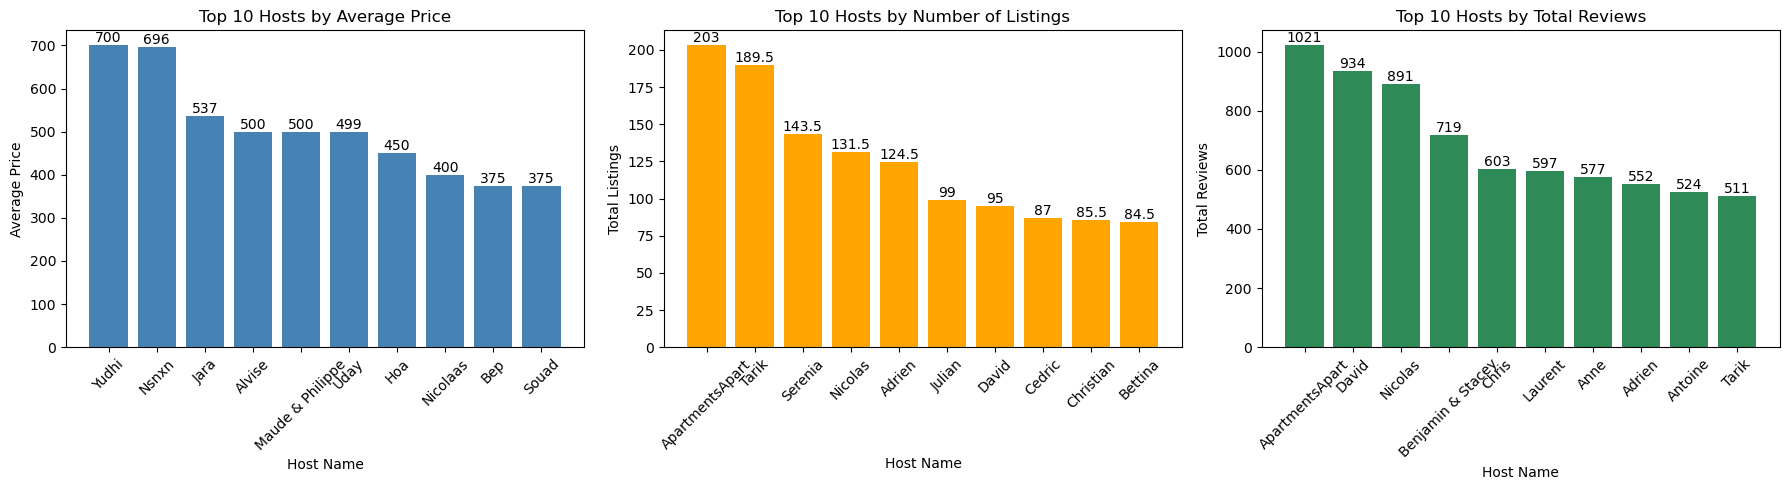

In [29]:
plt.figure(figsize=(18, 5))

# TOP 10 HOSTS BY AVERAGE PRICE
plt.subplot(1, 3, 1)

top_price_hosts = (belgium_df.groupby("host_name")["price"].mean().sort_values(ascending=False).head(10).reset_index())

ax1 = plt.bar(top_price_hosts["host_name"],top_price_hosts["price"],color="steelblue")

plt.bar_label(ax1, fmt="%.0f")
plt.title("Top 10 Hosts by Average Price")
plt.xlabel("Host Name")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

# TOP 10 HOSTS BY NUMBER OF LISTINGS
plt.subplot(1, 3, 2)

top_listing_hosts = (belgium_df.groupby("host_name")["host_total_listings_count"].sum().sort_values(ascending=False).head(10).reset_index())

ax2 = plt.bar(top_listing_hosts["host_name"],top_listing_hosts["host_total_listings_count"],color="orange")

plt.bar_label(ax2)
plt.title("Top 10 Hosts by Number of Listings")
plt.xlabel("Host Name")
plt.ylabel("Total Listings")
plt.xticks(rotation=45)

# TOP 10 HOSTS BY TOTAL REVIEWS
plt.subplot(1, 3, 3)

top_review_hosts = (belgium_df.groupby("host_name")["number_of_reviews"].sum().sort_values(ascending=False).head(10).reset_index())

ax3 = plt.bar(top_review_hosts["host_name"],top_review_hosts["number_of_reviews"],color="seagreen")

plt.bar_label(ax3)
plt.title("Top 10 Hosts by Total Reviews")
plt.xlabel("Host Name")
plt.ylabel("Total Reviews")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Listing & Host Performance – Insights

1. A small number of hosts charge significantly higher average prices, indicating that premium pricing is concentrated among a few top-performing hosts.

2. Hosts managing a larger number of listings clearly stand out, suggesting the presence of professional or large-scale hosts in the Belgium Airbnb market.

3. Hosts with more listings also receive higher total reviews, showing that larger host portfolios tend to attract more customer engagement and bookings.


## Geospatial and Location-Based Insights

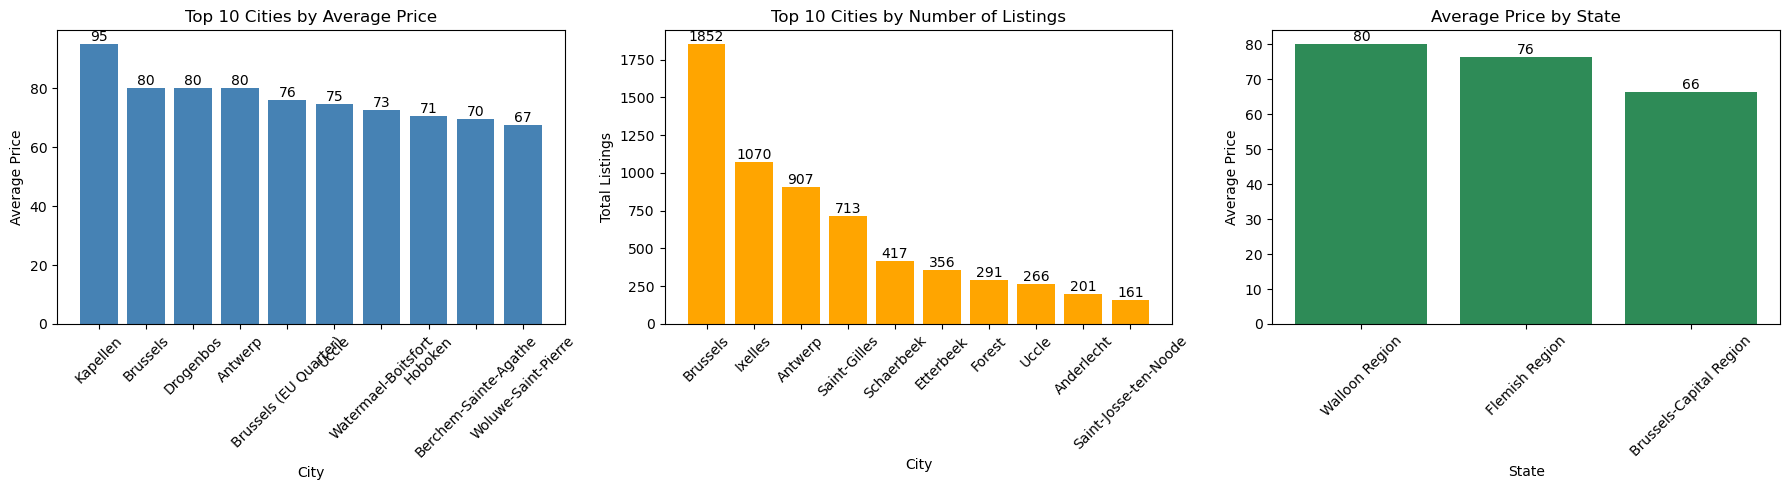

In [30]:
plt.figure(figsize=(18, 5))

# 1. Top 10 Cities by Average Price
plt.subplot(1, 3, 1)

avg_price_city = (belgium_df.groupby("city")["price"].mean().sort_values(ascending=False).head(10).reset_index())

ax1 = plt.bar(avg_price_city["city"], avg_price_city["price"],color="steelblue")
plt.bar_label(ax1, fmt="%.0f")

plt.title("Top 10 Cities by Average Price")
plt.xlabel("City")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

# 2. Top 10 Cities by Number of Listings
plt.subplot(1, 3, 2)

listing_city = (belgium_df.groupby("city")["id"].count().sort_values(ascending=False).head(10).reset_index(name="total_listings"))

ax2 = plt.bar(listing_city["city"], listing_city["total_listings"],color="orange")
plt.bar_label(ax2)

plt.title("Top 10 Cities by Number of Listings")
plt.xlabel("City")
plt.ylabel("Total Listings")
plt.xticks(rotation=45)

# 3. Average Price by State
plt.subplot(1, 3, 3)

avg_price_state = (belgium_df.groupby("state")["price"].mean().sort_values(ascending=False).reset_index())

ax3 = plt.bar(avg_price_state["state"], avg_price_state["price"],color="seagreen")
plt.bar_label(ax3, fmt="%.0f")

plt.title("Average Price by State")
plt.xlabel("State")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Geospatial and Location-Based Insights – Insights (Belgium)

1. Kapellen and Brussels show the highest average prices, indicating that certain cities command premium pricing due to location advantages or demand factors.

2. Brussels clearly dominates in terms of listing volume, making it the most competitive and saturated Airbnb market in Belgium.

3. The Walloon Region has the highest average prices among states, while the Brussels-Capital Region shows comparatively lower average prices, suggesting regional differences in pricing strategies and market dynamics.


## Customer Experience and Satisfaction

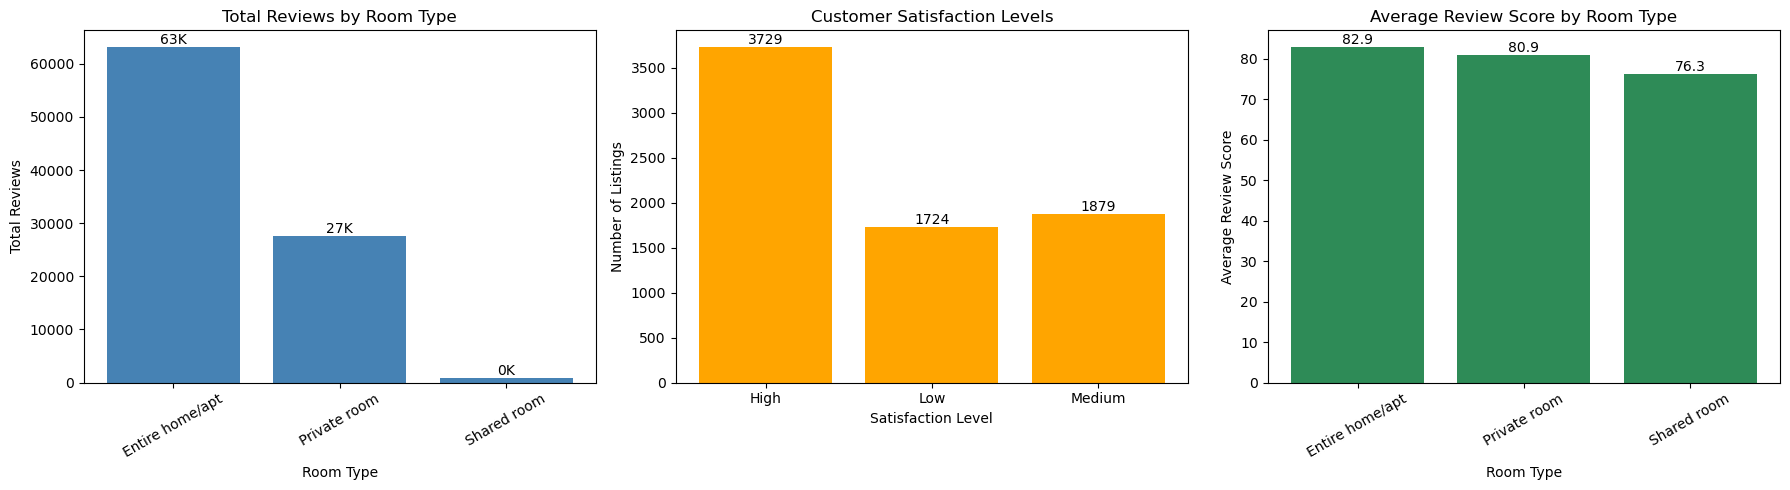

In [31]:
plt.figure(figsize=(18, 5))

# 1. Customer engagement across different room types

plt.subplot(1, 3, 1)

reviews_by_room = (belgium_df.groupby("room_type")["number_of_reviews"].sum().sort_values(ascending=False))

ax1 = plt.bar(reviews_by_room.index, reviews_by_room.values,color="steelblue")
plt.bar_label(ax1, labels=[f"{int(v/1000)}K" for v in reviews_by_room.values])

plt.title("Total Reviews by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Total Reviews")
plt.xticks(rotation=30)


# 2. Overall customer satisfaction levels on Airbnb

plt.subplot(1, 3, 2)

belgium_df["rating_category"] = pd.cut(
    belgium_df["review_scores_rating"], bins=[0, 70, 90, 100],labels=["Low", "Medium", "High"]
)

belgium_df["rating_category"] = belgium_df["rating_category"].cat.add_categories("No Rating")
belgium_df["rating_category"] = belgium_df["rating_category"].fillna("No Rating")
belgium_df["rating_category"] = belgium_df["rating_category"].astype(str)

rating_distribution = belgium_df["rating_category"].value_counts().sort_index()

ax2 = plt.bar(rating_distribution.index, rating_distribution.values,color="orange")
plt.bar_label(ax2)

plt.title("Customer Satisfaction Levels")
plt.xlabel("Satisfaction Level")
plt.ylabel("Number of Listings")

# 3. Comparison of customer satisfaction across room types

plt.subplot(1, 3, 3)

avg_rating_by_room = (belgium_df.groupby("room_type")["review_scores_rating"].mean().sort_values(ascending=False))

ax3 = plt.bar(avg_rating_by_room.index, avg_rating_by_room.values,color="seagreen")
plt.bar_label(ax3, fmt="%.1f")

plt.title("Average Review Score by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Review Score")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Customer Experience & Satisfaction – Insights 

1. Entire homes receive the highest customer engagement, with a much larger number of total reviews compared to private and shared rooms.

2. Most Airbnb listings fall under the high satisfaction category, showing that customers are generally satisfied with their stay experiences in Belgium.

3. Entire homes also achieve the highest average review scores, followed closely by private rooms, while shared rooms tend to receive lower ratings.

## Property Attributes and Amenities

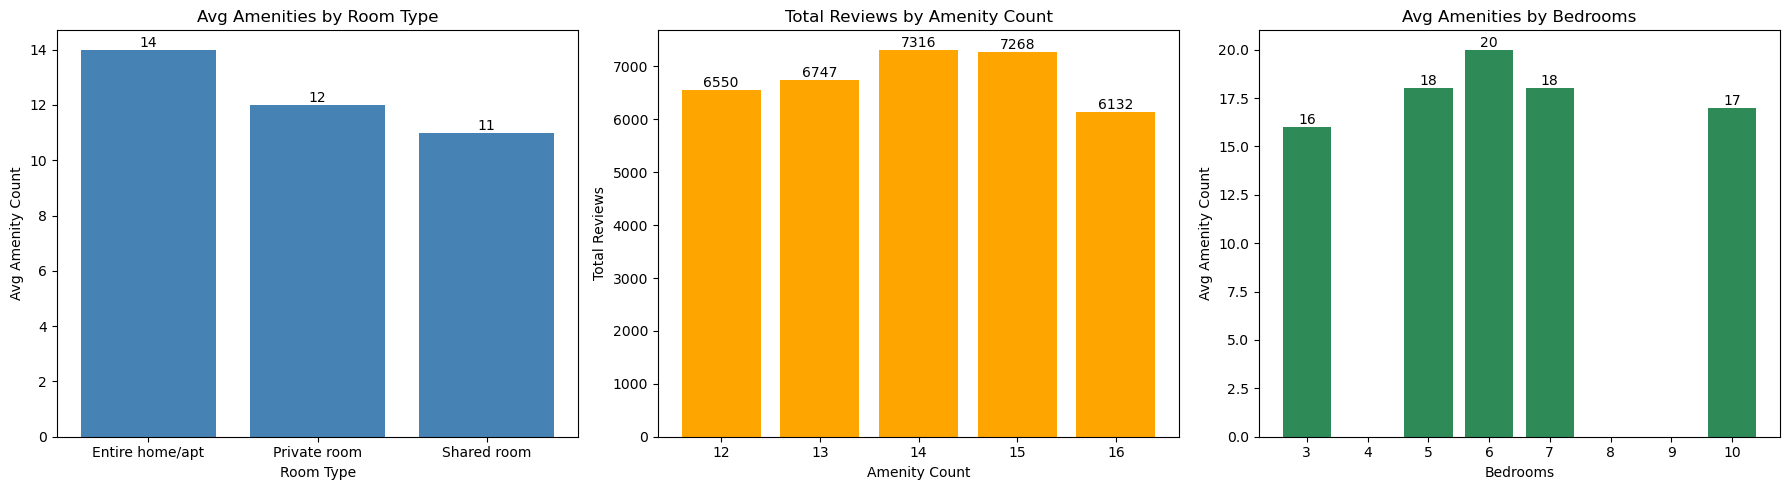

In [32]:
plt.figure(figsize=(18, 5))

# 4. Avg Amenities by Room Type
plt.subplot(1, 3, 1)

room_type_amenity = (belgium_df.groupby("room_type")["amenity_count"].mean().round().sort_values(ascending=False).head().reset_index())

ax1 = plt.bar(room_type_amenity["room_type"], room_type_amenity["amenity_count"], color="steelblue")
plt.bar_label(ax1)

plt.title("Avg Amenities by Room Type")
plt.ylabel("Avg Amenity Count")
plt.xlabel("Room Type")

# 5. Total Reviews by Amenity Count
plt.subplot(1, 3, 2)

amenity_wise_review = (belgium_df.groupby("amenity_count")["number_of_reviews"].sum().round().sort_values(ascending=False).head().reset_index())

ax2 = plt.bar(amenity_wise_review["amenity_count"], amenity_wise_review["number_of_reviews"], color="orange")
plt.bar_label(ax2)

plt.title("Total Reviews by Amenity Count")
plt.ylabel("Total Reviews")
plt.xlabel("Amenity Count")


# 6. Avg Amenities by Number of Bedrooms
plt.subplot(1, 3, 3)

no_bedroom_amenity = (belgium_df.groupby("bedrooms")["amenity_count"].mean().round().sort_values(ascending=False).head().reset_index())

ax3 = plt.bar(no_bedroom_amenity["bedrooms"], no_bedroom_amenity["amenity_count"], color="seagreen")
plt.bar_label(ax3)

plt.title("Avg Amenities by Bedrooms")
plt.ylabel("Avg Amenity Count")
plt.xlabel("Bedrooms")

plt.tight_layout()
plt.show()


## Property Attributes & Amenities – Insights

1. Entire homes offer the highest number of amenities, followed by private rooms, while shared rooms provide the fewest amenities, showing a clear difference in property offerings.

2. Listings with a moderate number of amenities receive the highest total reviews, suggesting that guests value useful amenities more than just a large count.

3. Larger properties (with more bedrooms) tend to offer more amenities, indicating that bigger homes are better equipped to meet diverse guest needs.

## Host Insights and Performance

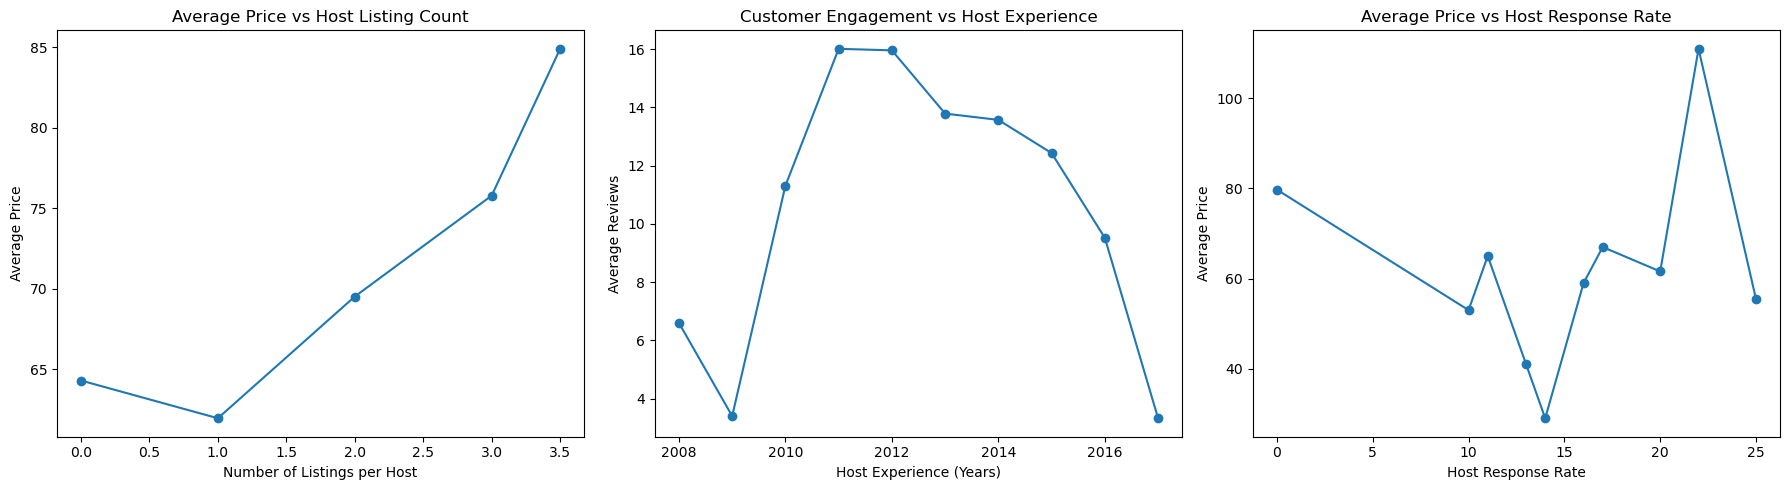

In [33]:
plt.figure(figsize=(18, 5))

# 1. Average Price vs Number of Listings

plt.subplot(1, 3, 1)

avg_price_by_listings = belgium_df.groupby("host_total_listings_count")["price"].mean().sort_index().head(10)

plt.plot(avg_price_by_listings.index,avg_price_by_listings.values,marker="o")

plt.title("Average Price vs Host Listing Count")
plt.xlabel("Number of Listings per Host")
plt.ylabel("Average Price")


# 2. Reviews Based on Host Listing Count

plt.subplot(1, 3, 2)

belgium_df["host_since"] = pd.to_datetime(belgium_df["host_since"], errors="coerce")
avg_reviews_by_experience = belgium_df.groupby("host_year")["number_of_reviews"].mean().sort_index().head(10)
plt.plot(avg_reviews_by_experience.index,avg_reviews_by_experience.values,marker="o")

plt.title("Customer Engagement vs Host Experience")
plt.xlabel("Host Experience (Years)")
plt.ylabel("Average Reviews")


# 3. Host Experience and Pricing Trend

plt.subplot(1, 3, 3)

avg_price_by_response = belgium_df.groupby("host_response_rate")["price"].mean().sort_index().head(10)
plt.plot(avg_price_by_response.index,avg_price_by_response.values,marker="o")

plt.title("Average Price vs Host Response Rate")
plt.xlabel("Host Response Rate")
plt.ylabel("Average Price")

plt.tight_layout()
plt.show()

## Host Insights & Performance – Insights

1. Hosts with more listings usually charge higher prices, showing that bigger hosts have more control over pricing.

2. More experienced hosts get more reviews, which means guests trust them more and book their listings more often.

3. Replying faster does not always mean higher prices, so response rate affects service quality more than pricing.


## Demand and Seasonal Trends

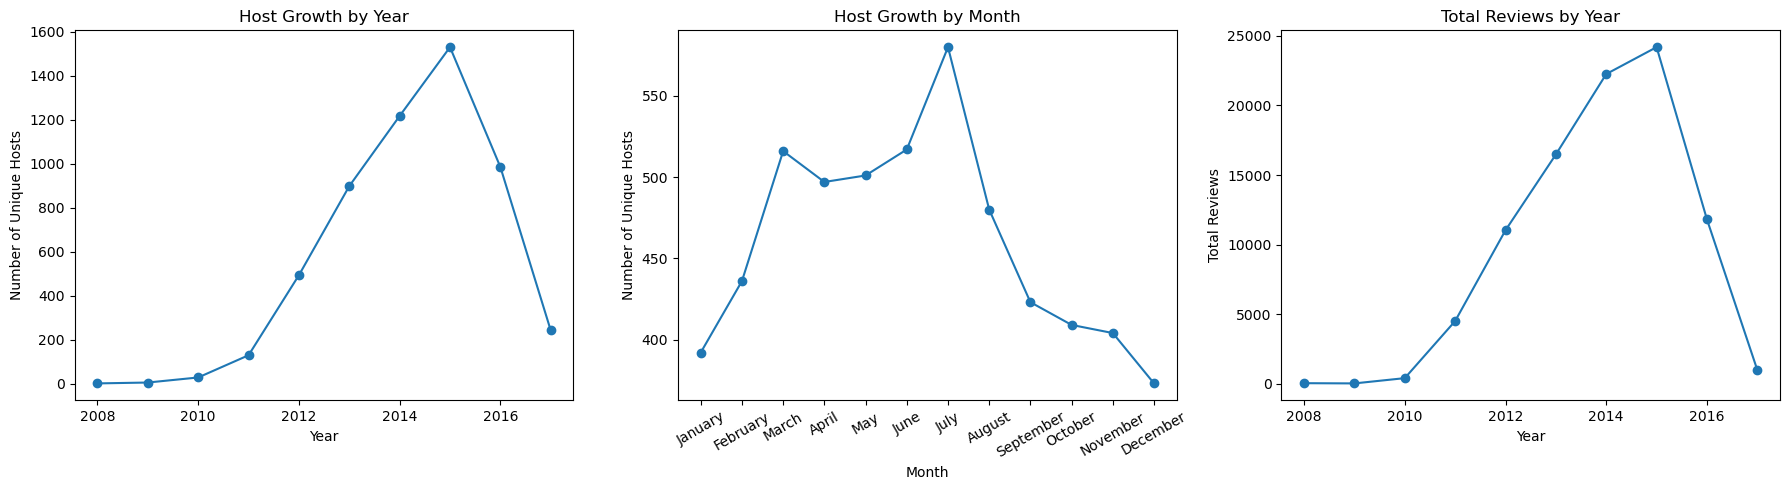

In [34]:
plt.figure(figsize=(18, 5))

# 1. Host growth trend over the years
plt.subplot(1, 3, 1)

hosts_by_year = (belgium_df.groupby("host_year")["host_id"].nunique().sort_index())

plt.plot(hosts_by_year.index, hosts_by_year.values, marker="o")

plt.title("Host Growth by Year")
plt.xlabel("Year")
plt.ylabel("Number of Unique Hosts")


# 2. Host growth pattern across months
plt.subplot(1, 3, 2)

hosts_by_month = (belgium_df.groupby("host_month_name")["host_id"].nunique().reindex([
        "January","February","March","April","May","June",
        "July","August","September","October","November","December"
    ]))

plt.plot(hosts_by_month.index, hosts_by_month.values, marker="o")

plt.title("Host Growth by Month")
plt.xlabel("Month")
plt.ylabel("Number of Unique Hosts")
plt.xticks(rotation=30)


# 3. Customer demand trend over the years
plt.subplot(1, 3, 3)

reviews_by_year = (belgium_df.groupby("host_year")["number_of_reviews"].sum().sort_index())

plt.plot(reviews_by_year.index, reviews_by_year.values, marker="o")

plt.title("Total Reviews by Year")
plt.xlabel("Year")
plt.ylabel("Total Reviews")

plt.tight_layout()
plt.show()

## Demand & Seasonal Trends – Insights

1. Host activity increased steadily over the years and peaked around 2015, showing strong growth in Airbnb participation before a noticeable decline afterward.

2. Summer months, especially June and July, show the highest host activity, indicating that demand is seasonal and strongest during the mid-year travel period.

3. Customer demand (reviews) also peaks during the same high-growth years, confirming that more hosts and more bookings happen during popular travel periods.

## Cancellation and Security Policies

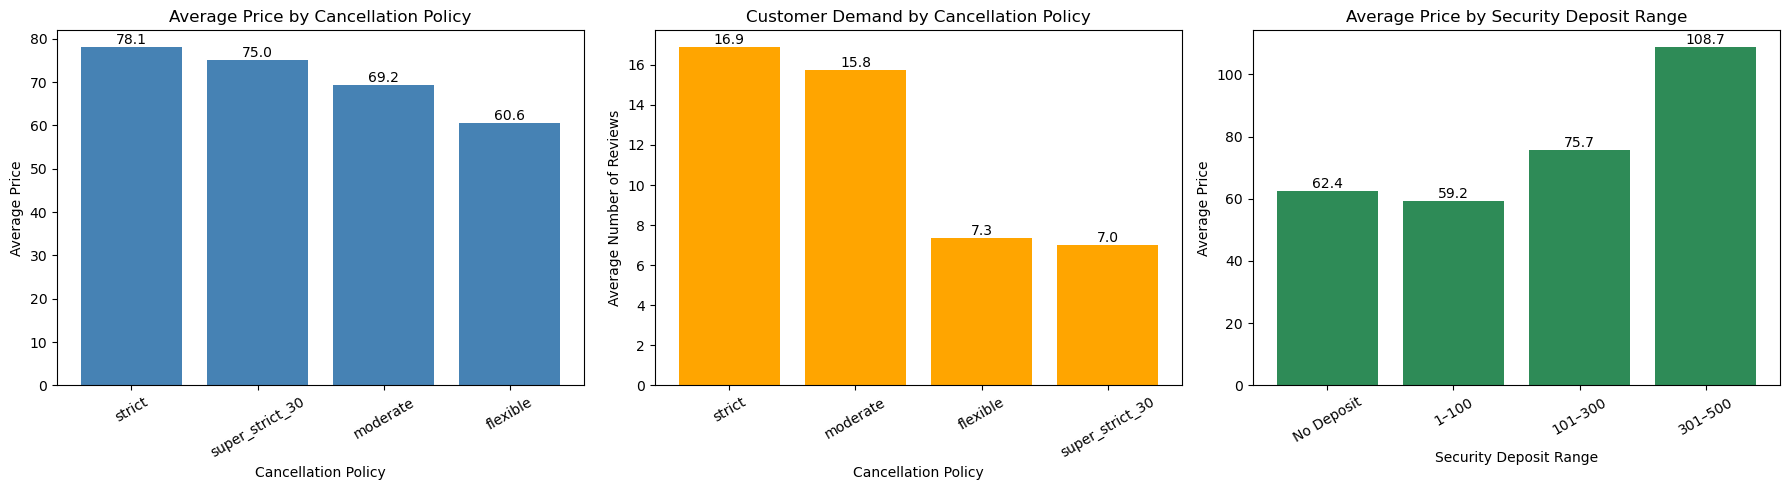

In [35]:
plt.figure(figsize=(18, 5))

# 1. How prices vary across different cancellation policies

plt.subplot(1, 3, 1)

avg_price_policy = (belgium_df.groupby("cancellation_policy")["price"].mean().sort_values(ascending=False))

ax1 = plt.bar(avg_price_policy.index,avg_price_policy.values,color=["steelblue"])

plt.bar_label(ax1, fmt="%.1f")
plt.title("Average Price by Cancellation Policy")
plt.xlabel("Cancellation Policy")
plt.ylabel("Average Price")
plt.xticks(rotation=30)


# 2. How customer demand differs by cancellation policy

plt.subplot(1, 3, 2)

avg_reviews_policy = (belgium_df.groupby("cancellation_policy")["number_of_reviews"].mean().sort_values(ascending=False))

ax2 = plt.bar(avg_reviews_policy.index,avg_reviews_policy.values,color=["orange"])

plt.bar_label(ax2, fmt="%.1f")
plt.title("Customer Demand by Cancellation Policy")
plt.xlabel("Cancellation Policy")
plt.ylabel("Average Number of Reviews")
plt.xticks(rotation=30)


# 3. How pricing changes across security deposit ranges

plt.subplot(1, 3, 3)

# SAFE upper bound (works even if max < 500)
max_deposit = belgium_df["security_deposit"].max()
max_deposit = max(max_deposit, 501)

belgium_df["security_deposit_range"] = pd.cut(
    belgium_df["security_deposit"],
    bins=[-1, 0, 100, 300, 500, max_deposit],
    labels=["No Deposit", "1–100", "101–300", "301–500", "500+"]
)

belgium_df["security_deposit_range"] = belgium_df["security_deposit_range"].astype(str)

avg_price_deposit = (
    belgium_df.groupby("security_deposit_range")["price"].mean()
    .reindex(["No Deposit", "1–100", "101–300", "301–500", "500+"])
)

ax3 = plt.bar(avg_price_deposit.index,avg_price_deposit.values,color="seagreen")

plt.bar_label(ax3, fmt="%.1f")
plt.title("Average Price by Security Deposit Range")
plt.xlabel("Security Deposit Range")
plt.ylabel("Average Price")
plt.xticks(rotation=30)



plt.tight_layout()
plt.show()

## Cancellation & Security Policies – Insights

1. Listings with stricter cancellation policies tend to charge higher prices, while flexible policies are usually priced lower to attract more bookings.

2. Customer demand is higher for strict and moderate policies, showing that guests are willing to book even with tighter rules if the listing meets their expectations.

3. Listings with higher security deposits generally have higher prices, indicating that premium or higher-value properties require more financial security from guests.

## Market Competitiveness Analysis

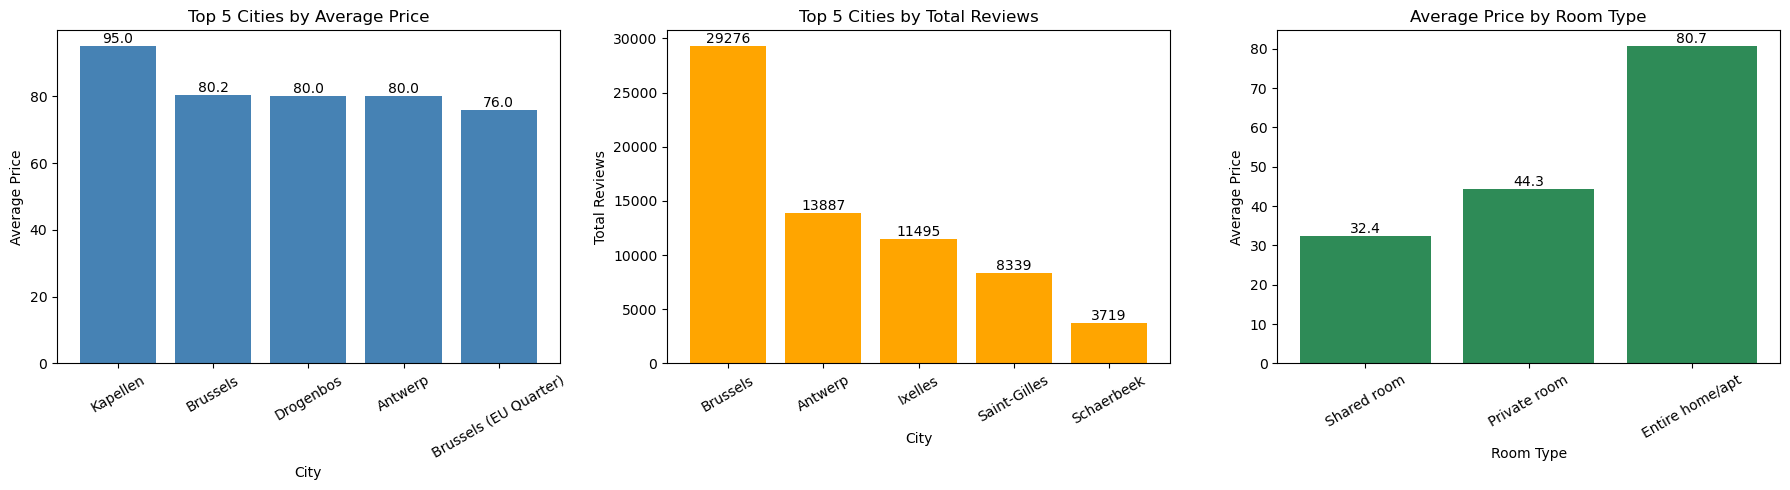

In [36]:
plt.figure(figsize=(18, 5))

# 1. City-wise price comparison

plt.subplot(1, 3, 1)

avg_price_city = (belgium_df.groupby("city")["price"].mean().sort_values(ascending=False).head(5))

ax1 = plt.bar(avg_price_city.index, avg_price_city.values, color="steelblue")
plt.bar_label(ax1, fmt="%.1f")

plt.title("Top 5 Cities by Average Price")
plt.xlabel("City")
plt.ylabel("Average Price")
plt.xticks(rotation=30)


# 2. City-wise customer engagement

plt.subplot(1, 3, 2)

total_reviews_city = (belgium_df.groupby("city")["number_of_reviews"].sum().sort_values(ascending=False).head(5))

ax2 = plt.bar(total_reviews_city.index, total_reviews_city.values, color="orange")
plt.bar_label(ax2)

plt.title("Top 5 Cities by Total Reviews")
plt.xlabel("City")
plt.ylabel("Total Reviews")
plt.xticks(rotation=30)


# 3. Room type price competitiveness

plt.subplot(1, 3, 3)

avg_price_room = (belgium_df.groupby("room_type")["price"].mean().sort_values())

ax3 = plt.bar(avg_price_room.index, avg_price_room.values, color="seagreen")
plt.bar_label(ax3, fmt="%.1f")

plt.title("Average Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price")
plt.xticks(rotation=30)


plt.tight_layout()
plt.show()

## Market Competitiveness – Insights

1. Kapellen has the highest average price, showing that some smaller cities can still be premium and competitive in pricing compared to major hubs.

2. Brussels dominates in total reviews, clearly making it the most competitive and active Airbnb market with the highest customer demand.

3. Entire homes are the least price-competitive option, as they are priced much higher than private and shared rooms, while shared rooms remain the most affordable choice.

#  STATISTICAL ANALYSIS

In [37]:
import math
from scipy.stats import norm
from scipy.stats import t

#  STATISTICAL ANALYSIS

## LISTING & HOST PERFORMANCE — STATISTICS

### **Business Question**

Do listings managed by **multi-listing hosts** receive more customer engagement than **single-listing hosts**?

### **Null Hypothesis (H₀)**

There is **no significant difference** in average number of reviews between single-listing and multi-listing hosts.

### **Alternative Hypothesis (H₁)**

Listings owned by **multi-listing hosts** receive **significantly more reviews** than those owned by single-listing hosts.

### **Statistical Test Used**

**Two-sample, right-tailed Z-test**
(Comparing means of two independent groups)

### **Significance Level**

α = 0.05

In [38]:
single_hosts = belgium_df[belgium_df["host_listings_count"] == 1]["number_of_reviews"].dropna()
multi_hosts  = belgium_df[belgium_df["host_listings_count"] > 1]["number_of_reviews"].dropna()

mean1 = multi_hosts.mean()
mean2 = single_hosts.mean()
var1 = multi_hosts.var()
var2 = single_hosts.var()
n1 = len(multi_hosts)
n2 = len(single_hosts)

z_stat = (mean1 - mean2) / math.sqrt((var1/n1) + (var2/n2))
p_value = norm.sf(z_stat)
z_critical = norm.ppf(0.95)

print("Listing & Host Performance – Belgium")
print("--------------------------------")
print("Test Statistic      :", round(z_stat, 3))
print("P-value (one-tailed):", round(p_value, 4))
print("Critical Value      :", round(z_critical, 3))

if z_stat > z_critical:
    print("Conclusion: Reject H0 – Multi-listing hosts receive more reviews.")
else:
    print("Conclusion: Fail to Reject H0 – No strong evidence found.")

Listing & Host Performance – Belgium
--------------------------------
Test Statistic      : 9.661
P-value (one-tailed): 0.0
Critical Value      : 1.645
Conclusion: Reject H0 – Multi-listing hosts receive more reviews.


## CUSTOMER EXPERIENCE & SATISFACTION — STATISTICS

### **Business Question**

Is the **average customer review score** significantly **higher than 80** across Airbnb listings?

### **Null Hypothesis (H₀)**

The average review score is **less than or equal to 80**.

### **Alternative Hypothesis (H₁)**

The average review score is **greater than 80**.

### **Statistical Test Used**

**One-sample, right-tailed t-test**
(Mean compared to a benchmark value)

### **Significance Level**

α = 0.05

In [39]:
ratings = belgium_df["review_scores_rating"].dropna()

sample_mean = ratings.mean()
sample_var = ratings.var()
n = len(ratings)
benchmark = 80

z_stat = (sample_mean - benchmark) / math.sqrt(sample_var / n)
p_value = norm.sf(z_stat)
z_critical = norm.ppf(0.95)

print("\nCustomer Satisfaction – Belgium")
print("--------------------------------")
print("Test Statistic      :", round(z_stat, 3))
print("P-value (one-tailed):", round(p_value, 4))
print("Critical Value      :", round(z_critical, 3))

if z_stat > z_critical:
    print("Conclusion: Reject H0 – Customer ratings are higher than 80.")
else:
    print("Conclusion: Fail to Reject H0 – Ratings do not exceed benchmark.")


Customer Satisfaction – Belgium
--------------------------------
Test Statistic      : 9.239
P-value (one-tailed): 0.0
Critical Value      : 1.645
Conclusion: Reject H0 – Customer ratings are higher than 80.


## GEOSPATIAL / LOCATION-BASED PRICING — STATISTICS

### **Business Question**

Are Airbnb listings located in major **Belgian cities (Brussels and Antwerp)** priced significantly higher than listings in **other Belgian cities**?
### **Null Hypothesis (H₀)**

There is **no significant difference** in average price between **Belgian cities (Brussels and Antwerp)** and **other Belgian cities**.

### **Alternative Hypothesis (H₁)**

Listings in Paris have a **significantly higher average price**.

### **Statistical Test Used**

**Independent two-sample, right-tailed t-test**

### **Significance Level**

α = 0.05


In [40]:
major_city_price = belgium_df[belgium_df["city"].isin(["Brussels", "Antwerp"])]["price"].dropna()
other_city_price = belgium_df[~belgium_df["city"].isin(["Brussels", "Antwerp"])]["price"].dropna()

mean1 = major_city_price.mean()
mean2 = other_city_price.mean()
var1 = major_city_price.var()
var2 = other_city_price.var()
n1 = len(major_city_price)
n2 = len(other_city_price)

t_stat = (mean1 - mean2) / math.sqrt((var1/n1) + (var2/n2))
df = n1 + n2 - 2

p_value = t.sf(t_stat, df)
t_critical = t.ppf(0.95, df)

print("\nGeospatial Pricing Analysis – Belgium")
print("--------------------------------")
print("Test Statistic      :", round(t_stat, 3))
print("P-value (one-tailed):", round(p_value, 4))
print("Critical Value      :", round(t_critical, 3))

if t_stat > t_critical:
    print("Conclusion: Reject H0 – Major cities have higher prices.")
else:
    print("Conclusion: Fail to Reject H0 – Price difference is not significant.")


Geospatial Pricing Analysis – Belgium
--------------------------------
Test Statistic      : 15.431
P-value (one-tailed): 0.0
Critical Value      : 1.645
Conclusion: Reject H0 – Major cities have higher prices.


## PROPERTY ATTRIBUTES & AMENITIES — STATISTICS

### **Business Question**

Do listings with **more amenities** receive **higher customer engagement** (reviews)?

### **Null Hypothesis (H₀)**

The average number of reviews for listings with many amenities is **less than or equal to** listings with fewer amenities.

### **Alternative Hypothesis (H₁)**

Listings with **more amenities** receive **significantly more reviews**.

### **Statistical Test Used**

**Two-sample, right-tailed Z-test**

### **Significance Level**

α = 0.05


In [41]:
high_amenities = belgium_df[belgium_df["amenity_count"] >= 5]["number_of_reviews"].dropna()
low_amenities  = belgium_df[belgium_df["amenity_count"] < 5]["number_of_reviews"].dropna()

mean1 = high_amenities.mean()
mean2 = low_amenities.mean()
var1 = high_amenities.var()
var2 = low_amenities.var()
n1 = len(high_amenities)
n2 = len(low_amenities)

z_stat = (mean1 - mean2) / math.sqrt((var1/n1) + (var2/n2))
p_value = norm.sf(z_stat)
z_critical = norm.ppf(0.95)

print("\nAmenities Impact – Belgium")
print("--------------------------------")
print("Test Statistic      :", round(z_stat, 3))
print("P-value (one-tailed):", round(p_value, 4))
print("Critical Value      :", round(z_critical, 3))

if z_stat > z_critical:
    print("Conclusion: Reject H0 – More amenities lead to higher engagement.")
else:
    print("Conclusion: Fail to Reject H0 – Amenities impact is not strong.")



Amenities Impact – Belgium
--------------------------------
Test Statistic      : 5.586
P-value (one-tailed): 0.0
Critical Value      : 1.645
Conclusion: Reject H0 – More amenities lead to higher engagement.


## CANCELLATION & SECURITY POLICIES — STATISTICS

### **Business Question**

Do listings with **strict cancellation policies** have **higher average prices** than flexible policies?

### **Null Hypothesis (H₀)**

Average prices under strict cancellation policies are **less than or equal to** flexible policies.

### **Alternative Hypothesis (H₁)**

Listings with strict cancellation policies have **significantly higher prices**.

### **Statistical Test Used**

**Independent two-sample, right-tailed t-test**

### **Significance Level**

α = 0.05

In [42]:
strict_price = belgium_df[belgium_df["cancellation_policy"] == "strict"]["price"].dropna()
flex_price   = belgium_df[belgium_df["cancellation_policy"] == "flexible"]["price"].dropna()

mean1 = strict_price.mean()
mean2 = flex_price.mean()
var1 = strict_price.var()
var2 = flex_price.var()
n1 = len(strict_price)
n2 = len(flex_price)

t_stat = (mean1 - mean2) / math.sqrt((var1/n1) + (var2/n2))
df = n1 + n2 - 2

p_value = t.sf(t_stat, df)
t_critical = t.ppf(0.95, df)

print("\nCancellation Policy Analysis – Belgium")
print("--------------------------------")
print("Test Statistic      :", round(t_stat, 3))
print("P-value (one-tailed):", round(p_value, 4))
print("Critical Value      :", round(t_critical, 3))

if t_stat > t_critical:
    print("Conclusion: Reject H0 – Strict policies are priced higher.")
else:
    print("Conclusion: Fail to Reject H0 – No strong price difference.")


Cancellation Policy Analysis – Belgium
--------------------------------
Test Statistic      : 10.558
P-value (one-tailed): 0.0
Critical Value      : 1.645
Conclusion: Reject H0 – Strict policies are priced higher.


# MACHINE LEARNING MODELS

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.neighbors import KNeighborsRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Encoding

In [44]:
belgium_encoded = belgium_df.copy()

categorical_cols = belgium_encoded.select_dtypes(include=["object"]).columns

le = LabelEncoder()

for col in categorical_cols:
    belgium_encoded[col] = le.fit_transform(belgium_encoded[col].astype(str))

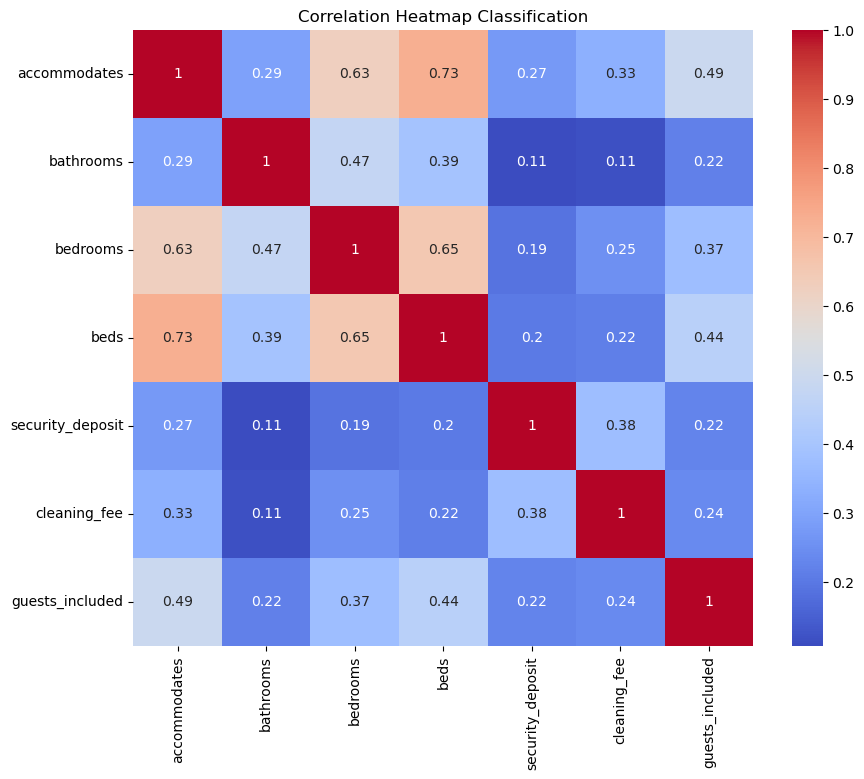

In [45]:
features = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'security_deposit', 'cleaning_fee', 'guests_included']

corr_df = belgium_encoded[features].dropna()

corr_matrix = corr_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap Classification")
plt.show()

## Simple Linear Regression: Price Prediction

In [46]:
features = ['accommodates']
target = 'price'

data = belgium_encoded[features + [target]].dropna()

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"--- Simple Linear Regression Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Intercept (C): {model.intercept_:.2f}")
print(f"Slope (Coefficient): {model.coef_[0]:.2f}")

--- Simple Linear Regression Model Evaluation ---
Mean Absolute Error (MAE): 25.20
Root Mean Squared Error (RMSE): 46.11
R-squared (R2) Score: 0.2628
Intercept (C): 67.77
Slope (Coefficient): 24.72


### Simple Linear Regression: Price Prediction

1. The model reports a Mean Absolute Error (MAE) of 25.20, meaning the predicted prices differ from actual prices by about 25 units on average, which is reasonable for a single-feature model.

2. The Root Mean Squared Error (RMSE) of 46.11 indicates that some listings have larger prediction errors, especially for higher-priced properties.

3. An R-squared value of 0.2628 shows that around 26% of the variation in listing prices is explained by accommodation capacity alone, which is expected for a simple model.

4. The positive slope (24.72) confirms that listings accommodating more guests generally have higher prices, with price increasing by roughly 25 units per additional guest capacity.

5. The intercept value of 67.77 represents the baseline price level when accommodation capacity is at its reference point, serving as a starting price estimate.

## Multiple Linear Regression: Price Prediction

In [47]:
features = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'security_deposit', 'cleaning_fee', 'guests_included']
target = 'price'

data = belgium_encoded[features + [target]].dropna()

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"--- Multiple Linear Regression Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Intercept (C): {model.intercept_:.2f}")
print(f"Slope (Coefficient): {model.coef_[0]:.2f}")

coefficients = pd.DataFrame({'Feature': features, 'Coefficient (Slope)': model.coef_})
print("\n--- Feature Coefficients ---")
print(coefficients.sort_values(by='Coefficient (Slope)', ascending=False))

--- Multiple Linear Regression Model Evaluation ---
Mean Absolute Error (MAE): 24.47
Root Mean Squared Error (RMSE): 43.97
R-squared (R2) Score: 0.3297
Intercept (C): 67.77
Slope (Coefficient): 13.16

--- Feature Coefficients ---
            Feature  Coefficient (Slope)
0      accommodates            13.164768
2          bedrooms             5.954328
1         bathrooms             5.886018
6   guests_included             5.024535
4  security_deposit             3.524321
5      cleaning_fee             2.679315
3              beds             2.511222


### Multiple Linear Regression: Price Prediction

1. The model reports a Mean Absolute Error (MAE) of 24.47 and an RMSE of 43.97, indicating better price prediction accuracy than simple linear regression by using multiple property features together.

2. The R-squared value of 0.3297 shows that about 33% of the variation in Airbnb prices is explained by the model, which is a reasonable improvement for a multi-feature regression.

3. Accommodates is the most influential feature (coefficient ≈ 13.16), confirming that listings allowing more guests generally charge higher prices.

4. Bedrooms and bathrooms also have strong positive effects, showing that larger and more comfortable properties tend to be priced higher.

5. Features such as cleaning fee, security deposit, guests included, and beds contribute positively but to a smaller extent, indicating they influence pricing but are less critical than capacity and property size.

## KNN Regression: Price Prediction

In [48]:
model = KNeighborsRegressor(n_neighbors=5)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"--- KNN Regression Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

--- KNN Regression Model Evaluation ---
Mean Absolute Error (MAE): 23.94
Root Mean Squared Error (RMSE): 42.26
R-squared (R2) Score: 0.3810


## Logistic Regression: Room Type Classification

In [49]:
features = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'amenity_count']
target = 'room_type'

data = belgium_encoded[features + [target]].dropna()
X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


print(f"--- Logistic Regression Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

--- Logistic Regression Model Evaluation ---
Accuracy Score: 0.8357

Confusion Matrix:
[[870  94   0]
 [131 355   0]
 [  6  10   1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       964
           1       0.77      0.73      0.75       486
           2       1.00      0.06      0.11        17

    accuracy                           0.84      1467
   macro avg       0.88      0.56      0.58      1467
weighted avg       0.84      0.84      0.83      1467



### Logistic Regression: Room Type Classification

1. The model achieves an overall accuracy of 83.57%, indicating good performance in classifying Airbnb room types using features such as price, capacity, and amenities.

2. Room Type 0 is classified very effectively, with high precision (0.86) and strong recall (0.90), meaning the model correctly identifies most listings in this category.

3. Room Type 1 shows moderate performance, with a recall of 0.73, indicating that while many listings are correctly identified, some are still misclassified.

4. Room Type 2 performs poorly due to very low support (only 17 listings), resulting in extremely low recall (0.06) and F1-score (0.11), clearly showing a class imbalance problem.

5. The weighted F1-score of 0.83 confirms that the model performs well overall for the majority of listings, but techniques such as class weighting, resampling, or alternative models could improve prediction for rare room types.

## K-NEAREST NEIGHBOURS: Room Type Classification

In [50]:
features = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'amenity_count']
target = 'room_type' 

data = belgium_encoded[features + [target]].dropna()
X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_clf = KNeighborsClassifier(n_neighbors=11)
knn_clf.fit(X_train_scaled, y_train)

y_pred = knn_clf.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"--- KNN Classification Evaluation ---")
print(f"Accuracy Score: {acc:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nDetailed Classification Report:")
print(report)

--- KNN Classification Evaluation ---
Accuracy Score: 0.8384

Confusion Matrix:
[[877  87   0]
 [133 353   0]
 [  5  12   0]]

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.89       964
           1       0.78      0.73      0.75       486
           2       0.00      0.00      0.00        17

    accuracy                           0.84      1467
   macro avg       0.55      0.55      0.55      1467
weighted avg       0.83      0.84      0.83      1467



### KNN: Room Type Classification

1. The KNN model achieves an overall accuracy of 83.84%, indicating good performance in predicting room types based on listing features such as price, size, and amenities.

2. Room Type 0 is classified very well, with high precision (0.86) and strong recall (0.91), meaning most listings in this category are correctly identified.

3. Room Type 1 also shows solid performance, with balanced precision (0.78) and recall (0.73), indicating reliable predictions for this common room category.

4. Room Type 2 performs very poorly, with precision, recall, and F1-score all equal to 0.00, due to extremely low support (only 17 listings), clearly highlighting a severe class imbalance issue.

5. The weighted F1-score of 0.83 confirms that the model performs well overall for the majority of listings, but techniques such as resampling, adjusting the value of k, or using alternative models could improve detection of rare room types.

## K-Means: Price Clustering

In [51]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

K = 2, Inertia = 9381.00, Silhouette = 0.422
K = 3, Inertia = 6566.84, Silhouette = 0.415
K = 4, Inertia = 5195.09, Silhouette = 0.415
K = 5, Inertia = 4044.46, Silhouette = 0.375
K = 6, Inertia = 3481.15, Silhouette = 0.377
K = 7, Inertia = 3045.90, Silhouette = 0.351
K = 8, Inertia = 2676.57, Silhouette = 0.348
K = 9, Inertia = 2403.09, Silhouette = 0.333
K = 10, Inertia = 2187.57, Silhouette = 0.344
K = 11, Inertia = 2016.66, Silhouette = 0.345


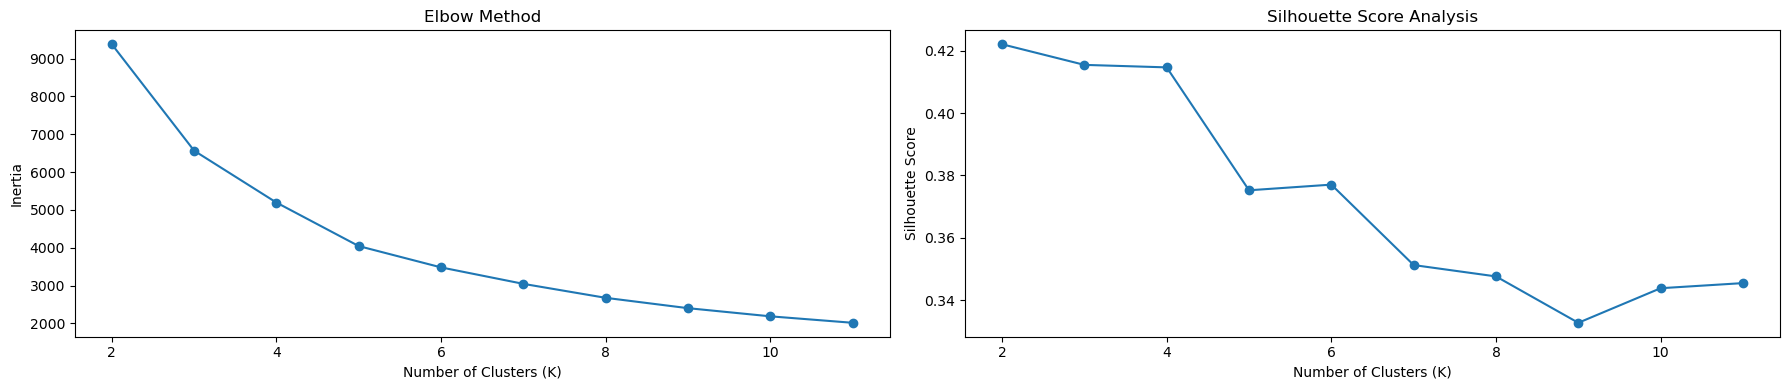

In [52]:
features = ['price', 'amenity_count']
data_clustering = belgium_encoded[features].dropna()

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_clustering)

# 1. Finding Optimal K

inertia_scores = []
silhouette_scores = []

for k in range(2, 12):
    model = KMeans(n_clusters=k, random_state=3, n_init=10)
    labels = model.fit_predict(data_scaled)

    inertia_scores.append(model.inertia_)
    silhouette_scores.append(silhouette_score(data_scaled, labels))

    print(f"K = {k}, Inertia = {model.inertia_:.2f}, Silhouette = {silhouette_score(data_scaled, labels):.3f}")

# 2. Elbow Plot

plt.figure(figsize=(18,4))
plt.subplot(1,2,1)
plt.plot(range(2, 12), inertia_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

# 3. Silhouette Score Plot

plt.subplot(1,2,2)
plt.plot(range(2, 12), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Analysis")

plt.tight_layout()
plt.show()


Cluster Distribution:
cluster
0.0    2837
4.0    2704
3.0    1052
2.0     676
1.0      63
Name: count, dtype: int64

Cluster Centroids:
        price  amenity_count
0   55.487134      14.407825
1  420.968254      18.984127
2  151.183432      15.544379
3   71.114068      21.515209
4   50.850592       8.427515


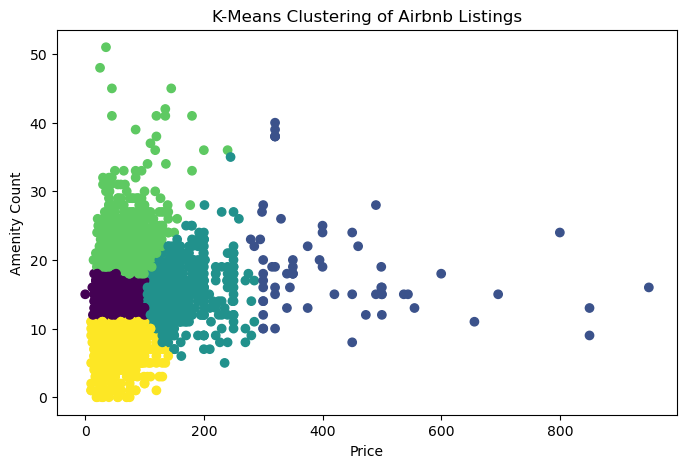

In [53]:
# 4. Final Model (Chosen K)

final_k = 5  
final_model = KMeans(n_clusters=final_k, random_state=3)
belgium_encoded.loc[data_clustering.index, "cluster"] = final_model.fit_predict(data_scaled)

# 5. Cluster Distribution

print("\nCluster Distribution:")
print(belgium_encoded["cluster"].value_counts())

# 6. Cluster Centroids (Original Scale)

centroids = pd.DataFrame(scaler.inverse_transform(final_model.cluster_centers_), columns=features)

print("\nCluster Centroids:")
print(centroids)

# 7. Cluster Visualization

plt.figure(figsize=(8,5))
plt.scatter(data_clustering["price"],data_clustering["amenity_count"], c=belgium_encoded.loc[data_clustering.index, "cluster"],cmap="viridis")
plt.xlabel("Price")
plt.ylabel("Amenity Count")
plt.title("K-Means Clustering of Airbnb Listings")
plt.show()


### K-Means: Price Clustering

1. Even though fewer clusters (such as 2 or 3) show slightly better technical scores, selecting 5 clusters makes more business sense as it clearly separates listings into budget, mid-range, and premium segments.

2. The elbow chart indicates that after K = 5, the reduction in inertia becomes minimal, meaning additional clusters do not provide meaningful new insights.

3. The cluster centers highlight clear listing types, including low-priced homes with fewer amenities, moderately priced listings with balanced features, and high-priced listings offering more amenities.

4. Most listings fall into the budget and mid-range clusters, while high-end and premium listings form a smaller portion of the market.

5. This clustering helps better understand the Belgian Airbnb market by showing how price and amenities move together, supporting pricing strategy and identifying areas where hosts can improve listings